In [1]:
from ema_workbench import (
    Model,
    MultiprocessingEvaluator,
    ScalarOutcome,
    IntegerParameter,
    optimize,
    Scenario,
)
from ema_workbench.em_framework.optimization import EpsilonProgress
from ema_workbench.util import ema_logging
from problem_formulation import get_model_for_problem_formulation
import matplotlib.pyplot as plt
import seaborn as sns

<class 'ema_workbench.em_framework.model.Model'>


[MainProcess/INFO] pool started with 12 workers
100%|████████████████████████████████████████| 200/200 [00:17<00:00, 11.35it/s]
[MainProcess/INFO] optimization completed, found 97 solutions
[MainProcess/INFO] terminating pool


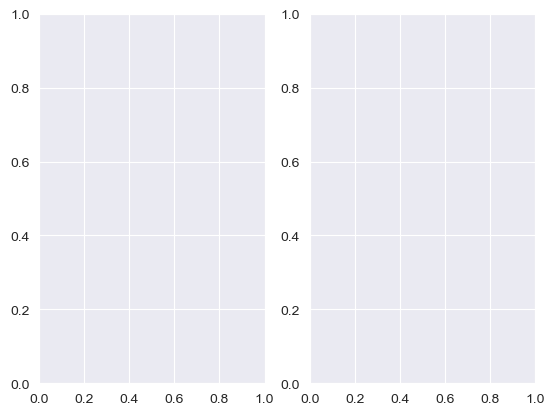

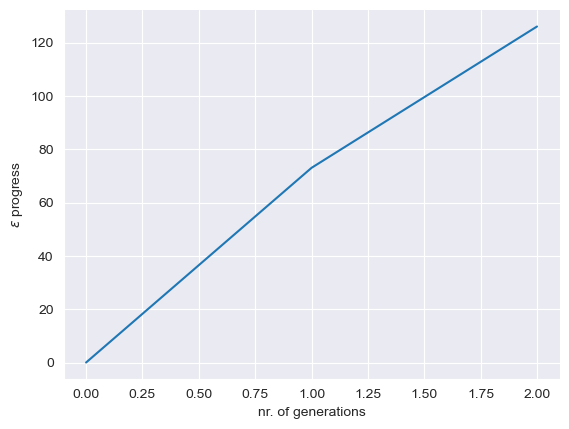

In [2]:
if __name__ == "__main__":
    ema_logging.log_to_stderr(ema_logging.INFO)

    model, steps = get_model_for_problem_formulation(3)
    print(type(model))

    reference_values = {
        "Bmax": 175,
        "Brate": 1.5,
        "pfail": 0.5,
        "discount rate 0": 3.5,
        "discount rate 1": 3.5,
        "discount rate 2": 3.5,
        "ID flood wave shape": 4,
    }
    scen1 = {}

    for key in model.uncertainties:
        name_split = key.name.split("_")

        if len(name_split) == 1:
            scen1.update({key.name: reference_values[key.name]})

        else:
            scen1.update({key.name: reference_values[name_split[1]]})

    ref_scenario = Scenario("reference", **scen1)

    convergence_metrics = [EpsilonProgress()]

    espilon = [1e3] * len(model.outcomes)

    nfe = 200  # proof of principle only, way to low for actual use

    with MultiprocessingEvaluator(model) as evaluator:
        results, convergence = evaluator.optimize(
            nfe=nfe,
            searchover="levers",
            epsilons=espilon,
            convergence=convergence_metrics,
            reference=ref_scenario,
        )

    fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True)
    fig, ax1 = plt.subplots(ncols=1)
    ax1.plot(convergence.epsilon_progress)
    ax1.set_xlabel("nr. of generations")
    ax1.set_ylabel(r"$\epsilon$ progress")
    sns.despine()


In [3]:
for i in model.outcomes:
    print(i)

ScalarOutcome('A.1 Total Costs', variable_name=('A.1_Expected Annual Damage', 'A.1_Dike Investment Costs'), function=<function sum_over at 0x0000022C91DA89A0>)
ScalarOutcome('A.1_Expected Number of Deaths', variable_name=('A.1_Expected Number of Deaths',), function=<function sum_over at 0x0000022C91DA89A0>)
ScalarOutcome('A.2 Total Costs', variable_name=('A.2_Expected Annual Damage', 'A.2_Dike Investment Costs'), function=<function sum_over at 0x0000022C91DA89A0>)
ScalarOutcome('A.2_Expected Number of Deaths', variable_name=('A.2_Expected Number of Deaths',), function=<function sum_over at 0x0000022C91DA89A0>)
ScalarOutcome('A.3 Total Costs', variable_name=('A.3_Expected Annual Damage', 'A.3_Dike Investment Costs'), function=<function sum_over at 0x0000022C91DA89A0>)
ScalarOutcome('A.3_Expected Number of Deaths', variable_name=('A.3_Expected Number of Deaths',), function=<function sum_over at 0x0000022C91DA89A0>)
ScalarOutcome('A.4 Total Costs', variable_name=('A.4_Expected Annual Dama

C:\Users\milan\PycharmProjects\EMAworkbench\ema_workbench\analysis\parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


<Figure size 6000x1200 with 0 Axes>

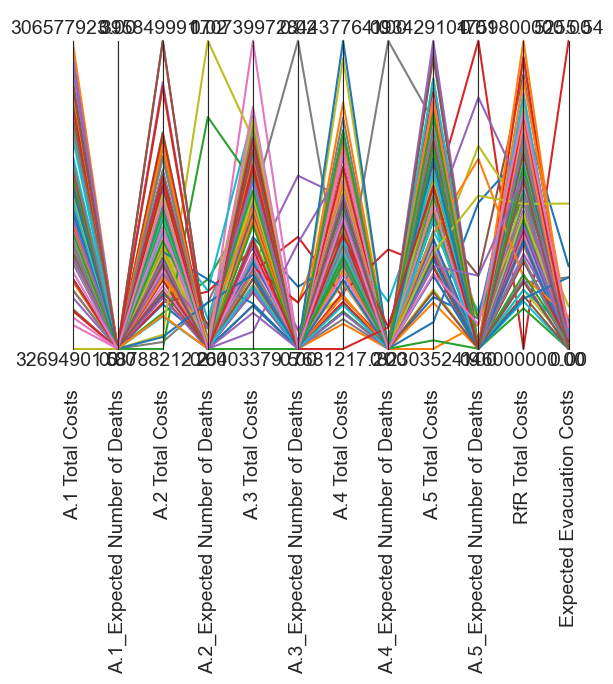

In [4]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

data = results.loc[:, [o.name for o in model.outcomes]]
limits = parcoords.get_limits(data)

plt.figure(figsize=(60, 12))  # make the figure wider; adjust numbers as you want

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(data)

plt.show()

In [5]:
import random

random.seed(20)

In [6]:
import os
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress
from ema_workbench import MultiprocessingEvaluator

# Zorg dat de map bestaat
os.makedirs("./archives", exist_ok=True)

# Verwijder bestaand bestand indien nodig
archive_path = "./archives/assignment_9_1.tar.gz"
if os.path.exists(archive_path):
    os.remove(archive_path)

# Convergence metrics
convergence_metrics = [
    ArchiveLogger(
        "./archives",
        [l.name.replace(" ", "") for l in model.levers],
        [o.name.replace(" ", "") for o in model.outcomes],
        base_filename="assignment_9_1.tar.gz",
    ),
    EpsilonProgress(),
]

# Run de optimalisatie
with MultiprocessingEvaluator(model) as evaluator:
    results, convergence = evaluator.optimize(
        nfe=1000,
        searchover='levers',
        convergence=convergence_metrics,
        epsilons=[0.01] * len(model.outcomes),
        reference=ref_scenario
    )

[MainProcess/INFO] pool started with 12 workers
100%|██████████████████████████████████████| 1000/1000 [01:39<00:00, 10.01it/s]
[MainProcess/INFO] optimization completed, found 354 solutions
[MainProcess/INFO] terminating pool


In [7]:
for i in model.levers:
    print(i)

0_RfR 0
0_RfR 1
0_RfR 2
1_RfR 0
1_RfR 1
1_RfR 2
2_RfR 0
2_RfR 1
2_RfR 2
3_RfR 0
3_RfR 1
3_RfR 2
4_RfR 0
4_RfR 1
4_RfR 2
EWS_DaysToThreat
A.1_DikeIncrease 0
A.1_DikeIncrease 1
A.1_DikeIncrease 2
A.2_DikeIncrease 0
A.2_DikeIncrease 1
A.2_DikeIncrease 2
A.3_DikeIncrease 0
A.3_DikeIncrease 1
A.3_DikeIncrease 2
A.4_DikeIncrease 0
A.4_DikeIncrease 1
A.4_DikeIncrease 2
A.5_DikeIncrease 0
A.5_DikeIncrease 1
A.5_DikeIncrease 2


In [8]:
archives = ArchiveLogger.load_archives("./archives/assignment_9_1.tar.gz")

In [9]:
archives

{0: Empty DataFrame
 Columns: [0_RfR0, 0_RfR1, 0_RfR2, 1_RfR0, 1_RfR1, 1_RfR2, 2_RfR0, 2_RfR1, 2_RfR2, 3_RfR0, 3_RfR1, 3_RfR2, 4_RfR0, 4_RfR1, 4_RfR2, EWS_DaysToThreat, A.1_DikeIncrease0, A.1_DikeIncrease1, A.1_DikeIncrease2, A.2_DikeIncrease0, A.2_DikeIncrease1, A.2_DikeIncrease2, A.3_DikeIncrease0, A.3_DikeIncrease1, A.3_DikeIncrease2, A.4_DikeIncrease0, A.4_DikeIncrease1, A.4_DikeIncrease2, A.5_DikeIncrease0, A.5_DikeIncrease1, A.5_DikeIncrease2, A.1TotalCosts, A.1_ExpectedNumberofDeaths, A.2TotalCosts, A.2_ExpectedNumberofDeaths, A.3TotalCosts, A.3_ExpectedNumberofDeaths, A.4TotalCosts, A.4_ExpectedNumberofDeaths, A.5TotalCosts, A.5_ExpectedNumberofDeaths, RfRTotalCosts, ExpectedEvacuationCosts]
 Index: []
 
 [0 rows x 43 columns],
 100:     0_RfR0  0_RfR1  0_RfR2  1_RfR0  1_RfR1  1_RfR2  2_RfR0  2_RfR1  2_RfR2  \
 0        0       0       0       0       0       0       1       1       1   
 1        1       1       0       0       1       0       0       1       1   
 2        1 

In [10]:
archives[100]

,0_RfR0,0_RfR1,0_RfR2,1_RfR0,1_RfR1,1_RfR2,2_RfR0,2_RfR1,2_RfR2,3_RfR0,...,A.2TotalCosts,A.2_ExpectedNumberofDeaths,A.3TotalCosts,A.3_ExpectedNumberofDeaths,A.4TotalCosts,A.4_ExpectedNumberofDeaths,A.5TotalCosts,A.5_ExpectedNumberofDeaths,RfRTotalCosts,ExpectedEvacuationCosts
0,0,0,0,0,0,0,1,1,1,1,...,2.281004e+08,0.001083,8.560912e+07,0.0,6.590773e+07,0.000000,1.578034e+08,0.000000,4.694000e+08,85.571674
1,1,1,0,0,1,0,0,1,1,0,...,1.881186e+08,0.002242,1.467362e+08,0.0,4.277965e+07,0.000000,1.032362e+08,0.000000,7.045000e+08,176.361846
2,1,0,0,0,0,1,1,0,1,0,...,1.831333e+08,0.000000,8.676551e+07,0.0,2.634470e+07,0.001074,9.455149e+07,0.000000,3.638000e+08,0.000000
3,1,0,1,0,0,1,1,0,0,0,...,1.530433e+08,0.000000,6.231890e+07,0.0,3.956834e+07,0.000000,1.086282e+08,0.000000,9.162000e+08,0.000000
4,1,0,0,0,1,0,0,1,1,0,...,1.372205e+08,0.000000,1.360111e+08,0.0,5.243976e+07,0.000000,8.110585e+07,0.000000,6.199000e+08,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,1,0,1,1,1,0,0,1,1,1,...,1.935144e+08,0.000000,8.771120e+07,0.0,3.783638e+07,0.000000,8.583115e+07,0.001873,1.420800e+09,178.453378
58,1,1,1,1,1,1,0,1,1,1,...,2.985036e+08,0.000000,7.808159e+07,0.0,4.326929e+07,0.000000,1.582131e+08,0.000000,1.345900e+09,0.000000
59,0,1,1,0,1,1,1,0,0,1,...,2.264069e+08,0.000000,8.815258e+07,0.0,3.375491e+07,0.000000,5.387028e+07,0.011541,1.268900e+09,1080.273719
60,1,1,0,1,1,1,0,1,1,1,...,2.098946e+08,0.000000,8.606854e+07,0.0,1.634729e+07,0.000000,1.087215e+08,0.000000,1.894700e+09,0.000000


In [11]:
archives[0]

,0_RfR0,0_RfR1,0_RfR2,1_RfR0,1_RfR1,1_RfR2,2_RfR0,2_RfR1,2_RfR2,3_RfR0,...,A.2TotalCosts,A.2_ExpectedNumberofDeaths,A.3TotalCosts,A.3_ExpectedNumberofDeaths,A.4TotalCosts,A.4_ExpectedNumberofDeaths,A.5TotalCosts,A.5_ExpectedNumberofDeaths,RfRTotalCosts,ExpectedEvacuationCosts


In [12]:
archives[1000]

,0_RfR0,0_RfR1,0_RfR2,1_RfR0,1_RfR1,1_RfR2,2_RfR0,2_RfR1,2_RfR2,3_RfR0,...,A.2TotalCosts,A.2_ExpectedNumberofDeaths,A.3TotalCosts,A.3_ExpectedNumberofDeaths,A.4TotalCosts,A.4_ExpectedNumberofDeaths,A.5TotalCosts,A.5_ExpectedNumberofDeaths,RfRTotalCosts,ExpectedEvacuationCosts
0,1,0,0,0,1,0,0,1,1,0,...,1.372205e+08,0.000000,1.360111e+08,0.000000,5.243976e+07,0.000000,8.110585e+07,0.000000,6.199000e+08,0.000000
1,0,1,0,0,0,0,1,0,0,0,...,3.441051e+08,0.000000,1.174267e+08,0.000000,7.627547e+07,0.000000,6.680428e+07,0.000000,2.365000e+08,0.000000
2,0,0,1,0,0,0,1,0,0,1,...,2.655508e+08,0.000000,9.899910e+07,0.000000,1.037540e+07,0.000410,9.059544e+07,0.000000,7.487000e+08,0.000000
3,1,1,1,1,0,0,0,0,0,1,...,6.251824e+07,0.001255,1.707400e+08,0.000000,2.740169e+07,0.000000,1.203586e+08,0.000000,1.347400e+09,610.219532
4,0,1,0,1,0,0,1,1,1,1,...,8.861311e+07,0.000000,9.310084e+07,0.000000,1.554479e+07,0.000021,7.258061e+07,0.000000,1.149100e+09,4.391596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,1,1,1,0,1,0,0,1,0,0,...,1.213148e+08,0.000000,6.851291e+07,0.005159,4.249410e+07,0.000000,7.897678e+07,0.009060,7.584000e+08,4024.520251
350,1,1,0,0,1,0,1,0,0,1,...,1.854485e+08,0.000000,4.639183e+07,0.001658,4.417232e+07,0.000000,9.450590e+06,0.001561,1.172300e+09,817.694548
351,0,1,1,0,0,0,1,0,0,0,...,1.500745e+08,0.000181,1.056530e+08,0.004104,1.662616e+07,0.000367,6.629411e+07,0.000000,1.999000e+08,212.071473
352,0,1,0,1,0,1,0,0,0,0,...,2.309216e+08,0.000000,9.738734e+07,0.022041,9.336769e+06,0.000440,8.898446e+07,0.011815,1.032400e+09,1927.822774


In [13]:
# Just take one archive (e.g., 100 evaluations)
sample_archive = archives[0]
print(sample_archive.columns.tolist())

['0_RfR0', '0_RfR1', '0_RfR2', '1_RfR0', '1_RfR1', '1_RfR2', '2_RfR0', '2_RfR1', '2_RfR2', '3_RfR0', '3_RfR1', '3_RfR2', '4_RfR0', '4_RfR1', '4_RfR2', 'EWS_DaysToThreat', 'A.1_DikeIncrease0', 'A.1_DikeIncrease1', 'A.1_DikeIncrease2', 'A.2_DikeIncrease0', 'A.2_DikeIncrease1', 'A.2_DikeIncrease2', 'A.3_DikeIncrease0', 'A.3_DikeIncrease1', 'A.3_DikeIncrease2', 'A.4_DikeIncrease0', 'A.4_DikeIncrease1', 'A.4_DikeIncrease2', 'A.5_DikeIncrease0', 'A.5_DikeIncrease1', 'A.5_DikeIncrease2', 'A.1TotalCosts', 'A.1_ExpectedNumberofDeaths', 'A.2TotalCosts', 'A.2_ExpectedNumberofDeaths', 'A.3TotalCosts', 'A.3_ExpectedNumberofDeaths', 'A.4TotalCosts', 'A.4_ExpectedNumberofDeaths', 'A.5TotalCosts', 'A.5_ExpectedNumberofDeaths', 'RfRTotalCosts', 'ExpectedEvacuationCosts']


In [14]:
# Just take one archive (e.g., 100 evaluations)
sample_archive = archives[100]
print(sample_archive.columns.tolist())

['0_RfR0', '0_RfR1', '0_RfR2', '1_RfR0', '1_RfR1', '1_RfR2', '2_RfR0', '2_RfR1', '2_RfR2', '3_RfR0', '3_RfR1', '3_RfR2', '4_RfR0', '4_RfR1', '4_RfR2', 'EWS_DaysToThreat', 'A.1_DikeIncrease0', 'A.1_DikeIncrease1', 'A.1_DikeIncrease2', 'A.2_DikeIncrease0', 'A.2_DikeIncrease1', 'A.2_DikeIncrease2', 'A.3_DikeIncrease0', 'A.3_DikeIncrease1', 'A.3_DikeIncrease2', 'A.4_DikeIncrease0', 'A.4_DikeIncrease1', 'A.4_DikeIncrease2', 'A.5_DikeIncrease0', 'A.5_DikeIncrease1', 'A.5_DikeIncrease2', 'A.1TotalCosts', 'A.1_ExpectedNumberofDeaths', 'A.2TotalCosts', 'A.2_ExpectedNumberofDeaths', 'A.3TotalCosts', 'A.3_ExpectedNumberofDeaths', 'A.4TotalCosts', 'A.4_ExpectedNumberofDeaths', 'A.5TotalCosts', 'A.5_ExpectedNumberofDeaths', 'RfRTotalCosts', 'ExpectedEvacuationCosts']


In [15]:
print([l.name for l in model.levers])

['0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2', '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2', '4_RfR 0', '4_RfR 1', '4_RfR 2', 'EWS_DaysToThreat', 'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2', 'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2', 'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2', 'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2', 'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2']


In [16]:
first_archive = list(archives.values())[2]
print(first_archive.columns.tolist())

['0_RfR0', '0_RfR1', '0_RfR2', '1_RfR0', '1_RfR1', '1_RfR2', '2_RfR0', '2_RfR1', '2_RfR2', '3_RfR0', '3_RfR1', '3_RfR2', '4_RfR0', '4_RfR1', '4_RfR2', 'EWS_DaysToThreat', 'A.1_DikeIncrease0', 'A.1_DikeIncrease1', 'A.1_DikeIncrease2', 'A.2_DikeIncrease0', 'A.2_DikeIncrease1', 'A.2_DikeIncrease2', 'A.3_DikeIncrease0', 'A.3_DikeIncrease1', 'A.3_DikeIncrease2', 'A.4_DikeIncrease0', 'A.4_DikeIncrease1', 'A.4_DikeIncrease2', 'A.5_DikeIncrease0', 'A.5_DikeIncrease1', 'A.5_DikeIncrease2', 'A.1TotalCosts', 'A.1_ExpectedNumberofDeaths', 'A.2TotalCosts', 'A.2_ExpectedNumberofDeaths', 'A.3TotalCosts', 'A.3_ExpectedNumberofDeaths', 'A.4TotalCosts', 'A.4_ExpectedNumberofDeaths', 'A.5TotalCosts', 'A.5_ExpectedNumberofDeaths', 'RfRTotalCosts', 'ExpectedEvacuationCosts']


In [17]:
for nfe, archive in archives.items():
    print(f"NFE {nfe}: {len(archive)} rows")

NFE 0: 0 rows
NFE 100: 62 rows
NFE 1000: 354 rows


In [18]:
results

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,1,0,0,0,1,0,0,1,1,0,...,1.372205e+08,0.000000,1.360111e+08,0.000000,5.243976e+07,0.000000,8.110585e+07,0.000000,6.199000e+08,0.000000
1,0,1,0,0,0,0,1,0,0,0,...,3.441051e+08,0.000000,1.174267e+08,0.000000,7.627547e+07,0.000000,6.680428e+07,0.000000,2.365000e+08,0.000000
2,0,0,1,0,0,0,1,0,0,1,...,2.655508e+08,0.000000,9.899910e+07,0.000000,1.037540e+07,0.000410,9.059544e+07,0.000000,7.487000e+08,0.000000
3,1,1,1,1,0,0,0,0,0,1,...,6.251824e+07,0.001255,1.707400e+08,0.000000,2.740169e+07,0.000000,1.203586e+08,0.000000,1.347400e+09,610.219532
4,0,1,0,1,0,0,1,1,1,1,...,8.861311e+07,0.000000,9.310084e+07,0.000000,1.554479e+07,0.000021,7.258061e+07,0.000000,1.149100e+09,4.391596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,1,1,1,0,1,0,0,1,0,0,...,1.213148e+08,0.000000,6.851291e+07,0.005159,4.249410e+07,0.000000,7.897678e+07,0.009060,7.584000e+08,4024.520251
350,1,1,0,0,1,0,1,0,0,1,...,1.854485e+08,0.000000,4.639183e+07,0.001658,4.417232e+07,0.000000,9.450590e+06,0.001561,1.172300e+09,817.694548
351,0,1,1,0,0,0,1,0,0,0,...,1.500745e+08,0.000181,1.056530e+08,0.004104,1.662616e+07,0.000367,6.629411e+07,0.000000,1.999000e+08,212.071473
352,0,1,0,1,0,1,0,0,0,0,...,2.309216e+08,0.000000,9.738734e+07,0.022041,9.336769e+06,0.000440,8.898446e+07,0.011815,1.032400e+09,1927.822774


In [19]:
archives[0].columns

Index(['0_RfR0', '0_RfR1', '0_RfR2', '1_RfR0', '1_RfR1', '1_RfR2', '2_RfR0',
       '2_RfR1', '2_RfR2', '3_RfR0', '3_RfR1', '3_RfR2', '4_RfR0', '4_RfR1',
       '4_RfR2', 'EWS_DaysToThreat', 'A.1_DikeIncrease0', 'A.1_DikeIncrease1',
       'A.1_DikeIncrease2', 'A.2_DikeIncrease0', 'A.2_DikeIncrease1',
       'A.2_DikeIncrease2', 'A.3_DikeIncrease0', 'A.3_DikeIncrease1',
       'A.3_DikeIncrease2', 'A.4_DikeIncrease0', 'A.4_DikeIncrease1',
       'A.4_DikeIncrease2', 'A.5_DikeIncrease0', 'A.5_DikeIncrease1',
       'A.5_DikeIncrease2', 'A.1TotalCosts', 'A.1_ExpectedNumberofDeaths',
       'A.2TotalCosts', 'A.2_ExpectedNumberofDeaths', 'A.3TotalCosts',
       'A.3_ExpectedNumberofDeaths', 'A.4TotalCosts',
       'A.4_ExpectedNumberofDeaths', 'A.5TotalCosts',
       'A.5_ExpectedNumberofDeaths', 'RfRTotalCosts',
       'ExpectedEvacuationCosts'],
      dtype='object')

In [20]:
for nfe, archive in archives.items():
    if archive.empty:
        print(f"Skipping archive {nfe} — it's empty.")

Skipping archive 0 — it's empty.


In [21]:
for nfe, archive in archives.items():
    print(archive)

Empty DataFrame
Columns: [0_RfR0, 0_RfR1, 0_RfR2, 1_RfR0, 1_RfR1, 1_RfR2, 2_RfR0, 2_RfR1, 2_RfR2, 3_RfR0, 3_RfR1, 3_RfR2, 4_RfR0, 4_RfR1, 4_RfR2, EWS_DaysToThreat, A.1_DikeIncrease0, A.1_DikeIncrease1, A.1_DikeIncrease2, A.2_DikeIncrease0, A.2_DikeIncrease1, A.2_DikeIncrease2, A.3_DikeIncrease0, A.3_DikeIncrease1, A.3_DikeIncrease2, A.4_DikeIncrease0, A.4_DikeIncrease1, A.4_DikeIncrease2, A.5_DikeIncrease0, A.5_DikeIncrease1, A.5_DikeIncrease2, A.1TotalCosts, A.1_ExpectedNumberofDeaths, A.2TotalCosts, A.2_ExpectedNumberofDeaths, A.3TotalCosts, A.3_ExpectedNumberofDeaths, A.4TotalCosts, A.4_ExpectedNumberofDeaths, A.5TotalCosts, A.5_ExpectedNumberofDeaths, RfRTotalCosts, ExpectedEvacuationCosts]
Index: []

[0 rows x 43 columns]
    0_RfR0  0_RfR1  0_RfR2  1_RfR0  1_RfR1  1_RfR2  2_RfR0  2_RfR1  2_RfR2  \
0        0       0       0       0       0       0       1       1       1   
1        1       1       0       0       1       0       0       1       1   
2        1       0       0   

In [29]:
print("archive columns:", archive.columns.tolist())

archive columns: ['0_RfR0', '0_RfR1', '0_RfR2', '1_RfR0', '1_RfR1', '1_RfR2', '2_RfR0', '2_RfR1', '2_RfR2', '3_RfR0', '3_RfR1', '3_RfR2', '4_RfR0', '4_RfR1', '4_RfR2', 'EWS_DaysToThreat', 'A.1_DikeIncrease0', 'A.1_DikeIncrease1', 'A.1_DikeIncrease2', 'A.2_DikeIncrease0', 'A.2_DikeIncrease1', 'A.2_DikeIncrease2', 'A.3_DikeIncrease0', 'A.3_DikeIncrease1', 'A.3_DikeIncrease2', 'A.4_DikeIncrease0', 'A.4_DikeIncrease1', 'A.4_DikeIncrease2', 'A.5_DikeIncrease0', 'A.5_DikeIncrease1', 'A.5_DikeIncrease2', 'A.1TotalCosts', 'A.1_ExpectedNumberofDeaths', 'A.2TotalCosts', 'A.2_ExpectedNumberofDeaths', 'A.3TotalCosts', 'A.3_ExpectedNumberofDeaths', 'A.4TotalCosts', 'A.4_ExpectedNumberofDeaths', 'A.5TotalCosts', 'A.5_ExpectedNumberofDeaths', 'RfRTotalCosts', 'ExpectedEvacuationCosts']


In [28]:
from ema_workbench import HypervolumeMetric
from ema_workbench.em_framework.optimization import to_problem

reference_set = results
reference_set.columns = reference_set.columns.map(lambda x: x.replace(" ",""))

for lever in model.levers:
    lever.name = lever.name.replace(" ","")

for outcome in model.outcomes:
    outcome.name = outcome.name.replace(" ","")

problem = to_problem(model, searchover="levers")

print(problem.parameter_names)
print(problem.outcome_names)

print(reference_set)

hv = HypervolumeMetric(reference_set, problem)

hypervolume = [(nfe, hv.calculate(archive)) for nfe, archive in archives.items()]
hypervolume.sort(key=lambda x:x[0])
hypervolume = np.asarray(hypervolume)

['0_RfR0', '0_RfR1', '0_RfR2', '1_RfR0', '1_RfR1', '1_RfR2', '2_RfR0', '2_RfR1', '2_RfR2', '3_RfR0', '3_RfR1', '3_RfR2', '4_RfR0', '4_RfR1', '4_RfR2', 'EWS_DaysToThreat', 'A.1_DikeIncrease0', 'A.1_DikeIncrease1', 'A.1_DikeIncrease2', 'A.2_DikeIncrease0', 'A.2_DikeIncrease1', 'A.2_DikeIncrease2', 'A.3_DikeIncrease0', 'A.3_DikeIncrease1', 'A.3_DikeIncrease2', 'A.4_DikeIncrease0', 'A.4_DikeIncrease1', 'A.4_DikeIncrease2', 'A.5_DikeIncrease0', 'A.5_DikeIncrease1', 'A.5_DikeIncrease2']
['A.1TotalCosts', 'A.1_ExpectedNumberofDeaths', 'A.2TotalCosts', 'A.2_ExpectedNumberofDeaths', 'A.3TotalCosts', 'A.3_ExpectedNumberofDeaths', 'A.4TotalCosts', 'A.4_ExpectedNumberofDeaths', 'A.5TotalCosts', 'A.5_ExpectedNumberofDeaths', 'RfRTotalCosts', 'ExpectedEvacuationCosts']
     0_RfR0  0_RfR1  0_RfR2  1_RfR0  1_RfR1  1_RfR2  2_RfR0  2_RfR1  2_RfR2  \
0         1       0       0       0       1       0       0       1       1   
1         0       1       0       0       0       0       1       0       0 

EMAError: Parameter names ['0_RfR0', '0_RfR1', '0_RfR2', '1_RfR0', '1_RfR1', '1_RfR2', '2_RfR0', '2_RfR1', '2_RfR2', '3_RfR0', '3_RfR1', '3_RfR2', '4_RfR0', '4_RfR1', '4_RfR2', 'A.1_DikeIncrease0', 'A.1_DikeIncrease1', 'A.1_DikeIncrease2', 'A.2_DikeIncrease0', 'A.2_DikeIncrease1', 'A.2_DikeIncrease2', 'A.3_DikeIncrease0', 'A.3_DikeIncrease1', 'A.3_DikeIncrease2', 'A.4_DikeIncrease0', 'A.4_DikeIncrease1', 'A.4_DikeIncrease2', 'A.5_DikeIncrease0', 'A.5_DikeIncrease1', 'A.5_DikeIncrease2'] not found in archive

In [24]:
reference_set.columns

Index(['0_RfR0', '0_RfR1', '0_RfR2', '1_RfR0', '1_RfR1', '1_RfR2', '2_RfR0',
       '2_RfR1', '2_RfR2', '3_RfR0', '3_RfR1', '3_RfR2', '4_RfR0', '4_RfR1',
       '4_RfR2', 'EWS_DaysToThreat', 'A.1_DikeIncrease0', 'A.1_DikeIncrease1',
       'A.1_DikeIncrease2', 'A.2_DikeIncrease0', 'A.2_DikeIncrease1',
       'A.2_DikeIncrease2', 'A.3_DikeIncrease0', 'A.3_DikeIncrease1',
       'A.3_DikeIncrease2', 'A.4_DikeIncrease0', 'A.4_DikeIncrease1',
       'A.4_DikeIncrease2', 'A.5_DikeIncrease0', 'A.5_DikeIncrease1',
       'A.5_DikeIncrease2', 'A.1TotalCosts', 'A.1_ExpectedNumberofDeaths',
       'A.2TotalCosts', 'A.2_ExpectedNumberofDeaths', 'A.3TotalCosts',
       'A.3_ExpectedNumberofDeaths', 'A.4TotalCosts',
       'A.4_ExpectedNumberofDeaths', 'A.5TotalCosts',
       'A.5_ExpectedNumberofDeaths', 'RfRTotalCosts',
       'ExpectedEvacuationCosts'],
      dtype='object')

In [27]:
reference_set

,0_RfR0,0_RfR1,0_RfR2,1_RfR0,1_RfR1,1_RfR2,2_RfR0,2_RfR1,2_RfR2,3_RfR0,...,A.2TotalCosts,A.2_ExpectedNumberofDeaths,A.3TotalCosts,A.3_ExpectedNumberofDeaths,A.4TotalCosts,A.4_ExpectedNumberofDeaths,A.5TotalCosts,A.5_ExpectedNumberofDeaths,RfRTotalCosts,ExpectedEvacuationCosts
0,1,0,0,0,1,0,0,1,1,0,...,1.372205e+08,0.000000,1.360111e+08,0.000000,5.243976e+07,0.000000,8.110585e+07,0.000000,6.199000e+08,0.000000
1,0,1,0,0,0,0,1,0,0,0,...,3.441051e+08,0.000000,1.174267e+08,0.000000,7.627547e+07,0.000000,6.680428e+07,0.000000,2.365000e+08,0.000000
2,0,0,1,0,0,0,1,0,0,1,...,2.655508e+08,0.000000,9.899910e+07,0.000000,1.037540e+07,0.000410,9.059544e+07,0.000000,7.487000e+08,0.000000
3,1,1,1,1,0,0,0,0,0,1,...,6.251824e+07,0.001255,1.707400e+08,0.000000,2.740169e+07,0.000000,1.203586e+08,0.000000,1.347400e+09,610.219532
4,0,1,0,1,0,0,1,1,1,1,...,8.861311e+07,0.000000,9.310084e+07,0.000000,1.554479e+07,0.000021,7.258061e+07,0.000000,1.149100e+09,4.391596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,1,1,1,0,1,0,0,1,0,0,...,1.213148e+08,0.000000,6.851291e+07,0.005159,4.249410e+07,0.000000,7.897678e+07,0.009060,7.584000e+08,4024.520251
350,1,1,0,0,1,0,1,0,0,1,...,1.854485e+08,0.000000,4.639183e+07,0.001658,4.417232e+07,0.000000,9.450590e+06,0.001561,1.172300e+09,817.694548
351,0,1,1,0,0,0,1,0,0,0,...,1.500745e+08,0.000181,1.056530e+08,0.004104,1.662616e+07,0.000367,6.629411e+07,0.000000,1.999000e+08,212.071473
352,0,1,0,1,0,1,0,0,0,0,...,2.309216e+08,0.000000,9.738734e+07,0.022041,9.336769e+06,0.000440,8.898446e+07,0.011815,1.032400e+09,1927.822774


In [26]:
for i in model.levers:
    print(i)

0_RfR0
0_RfR1
0_RfR2
1_RfR0
1_RfR1
1_RfR2
2_RfR0
2_RfR1
2_RfR2
3_RfR0
3_RfR1
3_RfR2
4_RfR0
4_RfR1
4_RfR2
EWS_DaysToThreat
A.1_DikeIncrease0
A.1_DikeIncrease1
A.1_DikeIncrease2
A.2_DikeIncrease0
A.2_DikeIncrease1
A.2_DikeIncrease2
A.3_DikeIncrease0
A.3_DikeIncrease1
A.3_DikeIncrease2
A.4_DikeIncrease0
A.4_DikeIncrease1
A.4_DikeIncrease2
A.5_DikeIncrease0
A.5_DikeIncrease1
A.5_DikeIncrease2


In [67]:
print(type(problem.parameter_names))

<class 'list'>


In [73]:
print(dir(model))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', '_constraints_output', '_levers', '_outcomes', '_outcomes_output', '_output_variables', '_transform', '_uncertainties', 'as_dict', 'cleanup', 'constants', 'function', 'initialized', 'levers', 'model_init', 'name', 'outcomes', 'outcomes_output', 'output_variables', 'policy', 'reset_model', 'retrieve_output', 'run_experiment', 'run_model', 'uncertainties']


In [75]:
print(model.levers)

In [57]:
for i in problem.parameter_names:
    print(i)

0_RfR 0
0_RfR 1
0_RfR 2
1_RfR 0
1_RfR 1
1_RfR 2
2_RfR 0
2_RfR 1
2_RfR 2
3_RfR 0
3_RfR 1
3_RfR 2
4_RfR 0
4_RfR 1
4_RfR 2
EWS_DaysToThreat
A.1_DikeIncrease 0
A.1_DikeIncrease 1
A.1_DikeIncrease 2
A.2_DikeIncrease 0
A.2_DikeIncrease 1
A.2_DikeIncrease 2
A.3_DikeIncrease 0
A.3_DikeIncrease 1
A.3_DikeIncrease 2
A.4_DikeIncrease 0
A.4_DikeIncrease 1
A.4_DikeIncrease 2
A.5_DikeIncrease 0
A.5_DikeIncrease 1
A.5_DikeIncrease 2


In [66]:
problem.parameter_names

['0_RfR 0',
 '0_RfR 1',
 '0_RfR 2',
 '1_RfR 0',
 '1_RfR 1',
 '1_RfR 2',
 '2_RfR 0',
 '2_RfR 1',
 '2_RfR 2',
 '3_RfR 0',
 '3_RfR 1',
 '3_RfR 2',
 '4_RfR 0',
 '4_RfR 1',
 '4_RfR 2',
 'EWS_DaysToThreat',
 'A.1_DikeIncrease 0',
 'A.1_DikeIncrease 1',
 'A.1_DikeIncrease 2',
 'A.2_DikeIncrease 0',
 'A.2_DikeIncrease 1',
 'A.2_DikeIncrease 2',
 'A.3_DikeIncrease 0',
 'A.3_DikeIncrease 1',
 'A.3_DikeIncrease 2',
 'A.4_DikeIncrease 0',
 'A.4_DikeIncrease 1',
 'A.4_DikeIncrease 2',
 'A.5_DikeIncrease 0',
 'A.5_DikeIncrease 1',
 'A.5_DikeIncrease 2']

In [58]:
for i in problem.searchover:
    print(i)

l
e
v
e
r
s


In [30]:
problem.searchover

'levers'

In [32]:
for i in problem.outcome_names:
    print(i)

A.1 Total Costs
A.1_Expected Number of Deaths
A.2 Total Costs
A.2_Expected Number of Deaths
A.3 Total Costs
A.3_Expected Number of Deaths
A.4 Total Costs
A.4_Expected Number of Deaths
A.5 Total Costs
A.5_Expected Number of Deaths
RfR Total Costs
Expected Evacuation Costs


In [ ]:
results = []
with MultiprocessingEvaluator(model) as evaluator:
    # we run 5 seperate optimizations
    for _ in range(5):
        result = evaluator.optimize(
            nfe=5000, searchover="levers", epsilons=[0.05] * len(model.outcomes), reference=ref_scenario
        )
        results.append(result)

[MainProcess/INFO] pool started with 12 workers
  0%|                                                 | 0/5000 [00:00<?, ?it/s]

In [ ]:
from ema_workbench.em_framework.optimization import epsilon_nondominated, to_problem

problem = to_problem(model, searchover="levers")
epsilons = [0.05] * len(model.outcomes)
merged_archives = epsilon_nondominated(results, epsilons, problem)

In [ ]:
merged_archives.shape

In [ ]:
from ema_workbench.em_framework.optimization import ArchiveLogger, EpsilonProgress

# we need to store our results for each seed
results = []
convergences = []

with MultiprocessingEvaluator(model) as evaluator:
    # we run again for 5 seeds
    for i in range(5):
        # we create 2 covergence tracker metrics
        # the archive logger writes the archive to disk for every x nfe
        # the epsilon progress tracks during runtime
        convergence_metrics = [
            ArchiveLogger(
                "./archives",
                [l.name for l in model.levers],
                [o.name for o in model.outcomes],
                base_filename=f"{i}.tar.gz",
            ),
            EpsilonProgress(),
        ]

        result, convergence = evaluator.optimize(
            nfe=50000,
            searchover="levers",
            epsilons=[0.05] * len(model.outcomes),
            convergence=convergence_metrics,
            reference=ref_scenario
        )

        results.append(result)
        convergences.append(convergence)

In [ ]:
all_archives = []

for i in range(5):
    archives = ArchiveLogger.load_archives(f"./archives/{i}.tar.gz")
    all_archives.append(archives)

In [ ]:
from ema_workbench import (
    HypervolumeMetric,
    GenerationalDistanceMetric,
    EpsilonIndicatorMetric,
    InvertedGenerationalDistanceMetric,
    SpacingMetric,
)
from ema_workbench.em_framework.optimization import to_problem

problem = to_problem(model, searchover="levers")

reference_set = epsilon_nondominated(results, [0.05] * len(model.outcomes), problem)

hv = HypervolumeMetric(reference_set, problem)
gd = GenerationalDistanceMetric(reference_set, problem, d=1)
ei = EpsilonIndicatorMetric(reference_set, problem)
ig = InvertedGenerationalDistanceMetric(reference_set, problem, d=1)
sm = SpacingMetric(problem)


metrics_by_seed = []
for archives in all_archives:
    metrics = []
    for nfe, archive in archives.items():
        scores = {
            "generational_distance": gd.calculate(archive),
            "hypervolume": hv.calculate(archive),
            "epsilon_indicator": ei.calculate(archive),
            "inverted_gd": ig.calculate(archive),
            "spacing": sm.calculate(archive),
            "nfe": int(nfe),
        }
        metrics.append(scores)
    metrics = pd.DataFrame.from_dict(metrics)

    # sort metrics by number of function evaluations
    metrics.sort_values(by="nfe", inplace=True)
    metrics_by_seed.append(metrics)

In [ ]:
sns.set_style("white")
fig, axes = plt.subplots(nrows=6, figsize=(8, 12), sharex=True)

ax1, ax2, ax3, ax4, ax5, ax6 = axes

for metrics, convergence in zip(metrics_by_seed, convergences):
    ax1.plot(metrics.nfe, metrics.hypervolume)
    ax1.set_ylabel("hypervolume")

    ax2.plot(convergence.nfe, convergence.epsilon_progress)
    ax2.set_ylabel("$\epsilon$ progress")

    ax3.plot(metrics.nfe, metrics.generational_distance)
    ax3.set_ylabel("generational distance")

    ax4.plot(metrics.nfe, metrics.epsilon_indicator)
    ax4.set_ylabel("epsilon indicator")

    ax5.plot(metrics.nfe, metrics.inverted_gd)
    ax5.set_ylabel("inverted generational\ndistance")

    ax6.plot(metrics.nfe, metrics.spacing)
    ax6.set_ylabel("spacing")

ax6.set_xlabel("nfe")


sns.despine(fig)

plt.show()

C:\Users\milan\PycharmProjects\EMAworkbench\ema_workbench\analysis\parcoords.py:220: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(h_pad=0, w_pad=0)


<Figure size 6000x3000 with 0 Axes>

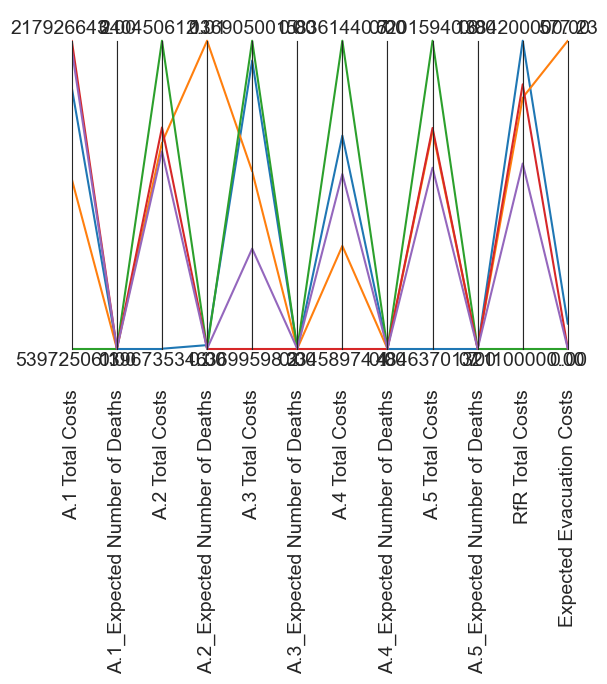

In [25]:
import matplotlib.pyplot as plt
from ema_workbench.analysis import parcoords

data = results.loc[:, [o.name for o in model.outcomes]]

# Define thresholds for "low" values, here using the 10th percentile for each
threshold_deaths = data['A.5_Expected Number of Deaths'].quantile(0.1)
threshold_costs = data['A.5 Total Costs'].quantile(0.1)

# Filter rows where both outcomes are below their thresholds
filtered_data = data[
    (data['A.5_Expected Number of Deaths'] <= threshold_deaths) &
    (data['A.5 Total Costs'] <= threshold_costs)
]

limits = parcoords.get_limits(filtered_data)

plt.figure(figsize=(60, 30))  # wide figure

paraxes = parcoords.ParallelAxes(limits)
paraxes.plot(filtered_data)

plt.show()

In [28]:
# Calculate 10th percentile thresholds for each column
threshold_costs = results['A.5 Total Costs'].quantile(0.1)
threshold_deaths = results['A.5_Expected Number of Deaths'].quantile(0.1)

# Filter rows where both are below the thresholds
filtered_results = results[
    (results['A.5 Total Costs'] <= threshold_costs) &
    (results['A.5_Expected Number of Deaths'] <= threshold_deaths)
]

In [29]:
filtered_results

,0_RfR 0,0_RfR 1,0_RfR 2,1_RfR 0,1_RfR 1,1_RfR 2,2_RfR 0,2_RfR 1,2_RfR 2,3_RfR 0,...,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
7,1,1,1,1,1,0,1,0,1,0,...,1.396735e+08,0.000087,1.321846e+08,0.0,5.069078e+07,0.0,4.846370e+07,0.0,1.384200e+09,46.613192
13,1,1,1,1,1,0,0,0,0,1,...,2.070968e+08,0.007404,1.058509e+08,0.0,4.177288e+07,0.0,5.804407e+07,0.0,1.187900e+09,577.226412
26,1,1,0,0,0,0,0,0,1,0,...,2.404506e+08,0.000000,1.369050e+08,0.0,5.836144e+07,0.0,6.201594e+07,0.0,3.211000e+08,0.000000
43,1,0,1,0,1,0,1,1,1,1,...,2.120685e+08,0.000000,6.369960e+07,0.0,3.345897e+07,0.0,5.817663e+07,0.0,1.233700e+09,0.000000
63,0,0,1,0,0,0,0,0,0,1,...,2.042489e+08,0.000000,8.749894e+07,0.0,4.758096e+07,0.0,5.642588e+07,0.0,9.604000e+08,0.000000


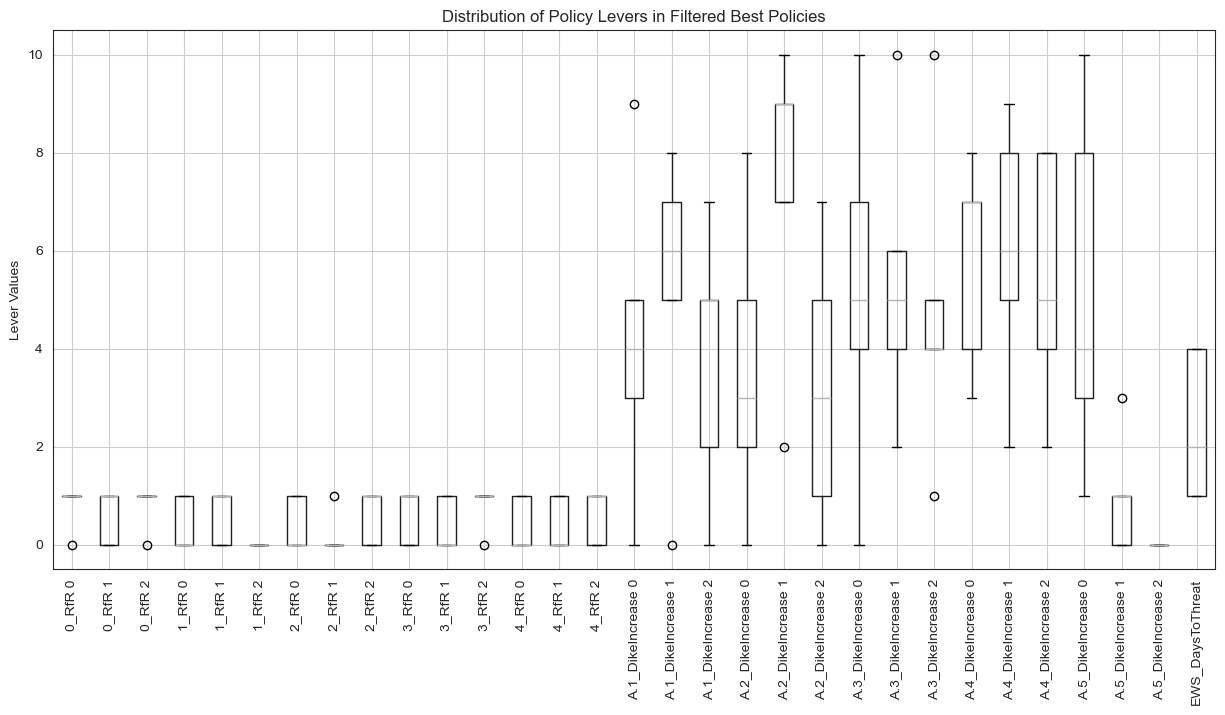

In [30]:
import matplotlib.pyplot as plt

# Assuming filtered_results is your filtered DataFrame from before

# List of policy levers (same as you provided)
policy_levers = [
    '0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2',
    '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2',
    '4_RfR 0', '4_RfR 1', '4_RfR 2',
    'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
    'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
    'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
    'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2',
    'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2',
    'EWS_DaysToThreat'
]

# Check if all levers exist in filtered_results columns (optional)
existing_levers = [lever for lever in policy_levers if lever in filtered_results.columns]

# Plot boxplot for those policy levers
plt.figure(figsize=(15, 7))
filtered_results[existing_levers].boxplot(rot=90)
plt.title("Distribution of Policy Levers in Filtered Best Policies")
plt.ylabel("Lever Values")
plt.show()